In [70]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import numpy as np

In [71]:
df = pd.read_parquet("../data/processed/deviation_scores.parquet")
with open("../config/deviation_params.json") as f:
    params = json.load(f)

raw_df = pd.read_parquet("../data/interim/data_10min.parquet") 

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 420767 entries, 2009-01-01 00:10:00 to 2016-12-31 23:50:00
Data columns (total 48 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   p (mbar)_median_1h     420218 non-null  float64
 1   p (mbar)_mad_1h        420203 non-null  float64
 2   p (mbar)_score_1h      420203 non-null  float64
 3   p (mbar)_score_sm_1h   420207 non-null  float64
 4   p (mbar)_median_3h     420182 non-null  float64
 5   p (mbar)_mad_3h        420131 non-null  float64
 6   p (mbar)_score_3h      420131 non-null  float64
 7   p (mbar)_score_sm_3h   420135 non-null  float64
 8   p (mbar)_median_12h    420020 non-null  float64
 9   p (mbar)_mad_12h       419807 non-null  float64
 10  p (mbar)_score_12h     419807 non-null  float64
 11  p (mbar)_score_sm_12h  419811 non-null  float64
 12  T (degC)_median_1h     420218 non-null  float64
 13  T (degC)_mad_1h        420203 non-null  float64
 14  T 

In [73]:
df.tail()

,p (mbar)_median_1h,p (mbar)_mad_1h,p (mbar)_score_1h,p (mbar)_score_sm_1h,p (mbar)_median_3h,p (mbar)_mad_3h,p (mbar)_score_3h,p (mbar)_score_sm_3h,p (mbar)_median_12h,p (mbar)_mad_12h,...,wv (m/s)_score_1h,wv (m/s)_score_sm_1h,wv (m/s)_median_3h,wv (m/s)_mad_3h,wv (m/s)_score_3h,wv (m/s)_score_sm_3h,wv (m/s)_median_12h,wv (m/s)_mad_12h,wv (m/s)_score_12h,wv (m/s)_score_sm_12h
Date Time,,,,,,,,,,,,,,,,,,,,,
2016-12-31 23:10:00,1000.380,0.2350,1.148936,0.938534,1000.905,0.7050,1.127660,1.101655,1002.455,2.2700,...,0.855172,0.759724,0.74,0.1925,0.935065,1.137667,0.780,0.28,0.785714,0.916667
2016-12-31 23:20:00,1000.265,0.2150,0.906977,1.018638,1000.755,0.6975,0.982079,1.086225,1002.440,2.3100,...,0.673077,0.530750,0.69,0.1925,0.103896,0.539303,0.765,0.28,0.339286,0.488095
2016-12-31 23:30:00,1000.160,0.2125,1.082353,1.046089,1000.675,0.6975,1.068100,1.059280,1002.395,2.3550,...,1.168317,0.898855,0.69,0.1925,2.337662,1.125541,0.765,0.28,1.339286,0.821429
2016-12-31 23:40:00,1000.090,0.2325,1.161290,1.050207,1000.580,0.6975,1.089606,1.046595,1002.360,2.3675,...,0.404255,0.748550,0.74,0.1925,1.766234,1.402597,0.765,0.28,1.125000,0.934524
2016-12-31 23:50:00,1000.000,0.2325,0.817204,1.020283,1000.480,0.6900,0.971014,1.042907,1002.330,2.3950,...,2.148936,1.240503,0.74,0.2475,3.030303,2.378066,0.765,0.28,2.589286,1.684524


## quick data checks

In [74]:
windows = params['windows']
cols = ["p (mbar)", "T (degC)", "rh (%)", "wv (m/s)"]

print('shape:', df.shape)
print('nan counts:\n', df.isna().sum().sort_values(ascending=False))

threshold = [3, 5, 8]

for col in cols:
    for w_name in windows:
        s = df[f"{col}_score_{w_name}"]
        print(col, w_name)
        for th in threshold:
            pct = (s > th).mean() * 100
            print(f"  >{th}: {pct:.4f}%")

shape: (420767, 48)
nan counts:
 wv (m/s)_mad_12h         1396
wv (m/s)_score_12h       1396
wv (m/s)_score_sm_12h    1386
wv (m/s)_median_12h       970
p (mbar)_score_12h        960
p (mbar)_mad_12h          960
T (degC)_mad_12h          960
T (degC)_score_12h        960
rh (%)_mad_12h            960
rh (%)_score_12h          960
p (mbar)_score_sm_12h     956
T (degC)_score_sm_12h     956
rh (%)_score_sm_12h       956
wv (m/s)_score_3h         748
wv (m/s)_mad_3h           748
p (mbar)_median_12h       747
rh (%)_median_12h         747
T (degC)_median_12h       747
wv (m/s)_score_sm_3h      738
wv (m/s)_median_3h        646
rh (%)_score_3h           636
rh (%)_mad_3h             636
T (degC)_mad_3h           636
T (degC)_score_3h         636
p (mbar)_mad_3h           636
p (mbar)_score_3h         636
T (degC)_score_sm_3h      632
p (mbar)_score_sm_3h      632
rh (%)_score_sm_3h        632
wv (m/s)_score_1h         604
wv (m/s)_mad_1h           604
wv (m/s)_score_sm_1h      594
p (mbar

## visual inspection per variable

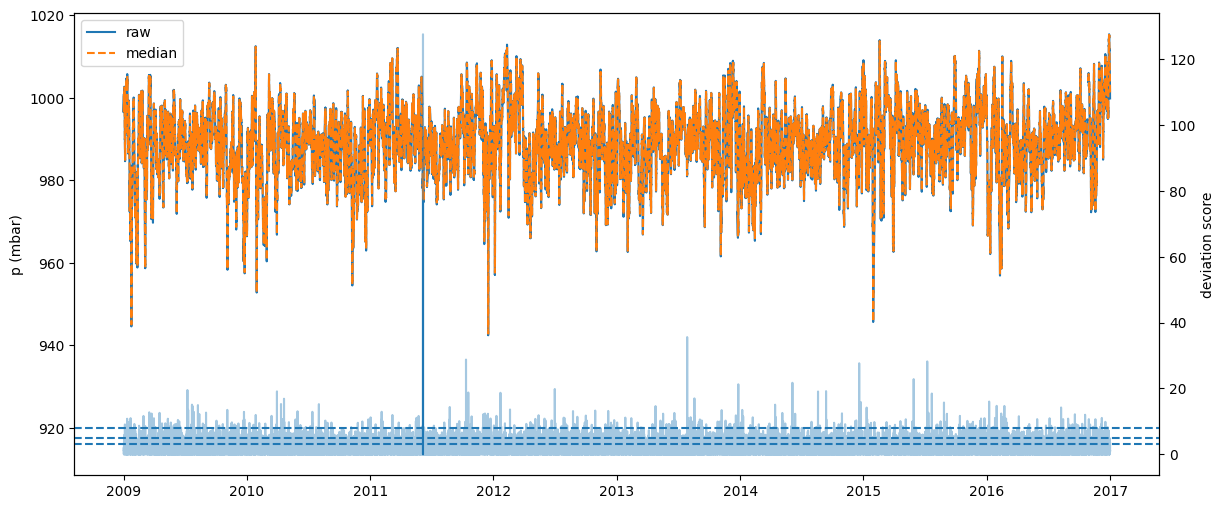

In [86]:
var = "p (mbar)"
w_name = "3h"

raw = raw_df[var]
median_t = df[f"{var}_median_{w_name}"]
score = df[f"{var}_score_{w_name}"]

fig, ax1 = plt.subplots(figsize=(14,6))

ax1.plot(raw, label="raw")
ax1.plot(median_t, label="median", linestyle="--")
ax1.set_ylabel(var)

ax2 = ax1.twinx()
ax2.plot(score, label="score", alpha=0.4)
ax2.axhline(3, linestyle="--")
ax2.axhline(5, linestyle="--")
ax2.axhline(8, linestyle="--")
ax2.set_ylabel("deviation score")

ax1.legend(loc="upper left")
plt.show()

## spike inspection

In [90]:
var = "p (mbar)"
w_name = "1h"


score = df[f"{var}_score_{w_name}"]
top = score.nlargest(5).index

for t in top:
    
    raw_window = raw_df.loc[
        t - pd.Timedelta("30min") :
        t + pd.Timedelta("30min")
    ][[var]]
    
    dev_window = df.loc[
        t - pd.Timedelta("30min") :
        t + pd.Timedelta("30min")
    ][[
        f"{var}_median_{w_name}",
        f"{var}_score_{w_name}"
    ]]

    merged = raw_window.join(dev_window)
    
    print("timestamp:", t)
    display(merged)


timestamp: 2011-06-06 13:20:00


,p (mbar),p (mbar)_median_1h,p (mbar)_score_1h
Date Time,,,
2011-06-06 12:50:00,977.58,977.575,0.050000
2011-06-06 13:00:00,977.61,977.575,0.424242
2011-06-06 13:10:00,969.32,977.540,82.199999
2011-06-06 13:20:00,913.60,977.485,440.586204
2011-06-06 13:30:00,914.10,973.415,14.266987
2011-06-06 13:40:00,917.40,943.360,1.519017
2011-06-06 13:50:00,917.40,917.400,0.000000


timestamp: 2011-06-06 13:10:00


,p (mbar),p (mbar)_median_1h,p (mbar)_score_1h
Date Time,,,
2011-06-06 12:40:00,977.51,977.605,0.745098
2011-06-06 12:50:00,977.58,977.575,0.050000
2011-06-06 13:00:00,977.61,977.575,0.424242
2011-06-06 13:10:00,969.32,977.540,82.199999
2011-06-06 13:20:00,913.60,977.485,440.586204
2011-06-06 13:30:00,914.10,973.415,14.266987
2011-06-06 13:40:00,917.40,943.360,1.519017


timestamp: 2010-03-21 14:00:00


,p (mbar),p (mbar)_median_1h,p (mbar)_score_1h
Date Time,,,
2010-03-21 13:30:00,984.33,984.335,0.062500
2010-03-21 13:40:00,984.35,984.345,0.250000
2010-03-21 13:50:00,984.42,984.345,3.750000
2010-03-21 14:00:00,985.12,984.345,38.749998
2010-03-21 14:10:00,985.50,984.385,26.235294
2010-03-21 14:20:00,985.71,984.770,2.211765
2010-03-21 14:30:00,986.00,985.310,0.941980


timestamp: 2011-05-04 15:50:00


,p (mbar),p (mbar)_median_1h,p (mbar)_score_1h
Date Time,,,
2011-05-04 15:20:00,992.47,992.490,1.000000
2011-05-04 15:30:00,992.49,992.485,0.250000
2011-05-04 15:40:00,992.66,992.500,8.000000
2011-05-04 15:50:00,993.20,992.500,34.999998
2011-05-04 16:00:00,993.43,992.575,9.500000
2011-05-04 16:10:00,993.47,992.930,1.542857
2011-05-04 16:20:00,993.57,993.315,0.641509


timestamp: 2016-05-22 21:20:00


,p (mbar),p (mbar)_median_1h,p (mbar)_score_1h
Date Time,,,
2016-05-22 20:50:00,979.92,979.910,0.500000
2016-05-22 21:00:00,979.91,979.910,0.000000
2016-05-22 21:10:00,980.09,979.910,9.000000
2016-05-22 21:20:00,980.60,979.915,34.249998
2016-05-22 21:30:00,980.81,980.005,8.473684
2016-05-22 21:40:00,980.90,980.345,1.510204
2016-05-22 21:50:00,981.00,980.705,0.694118


## baseline stability

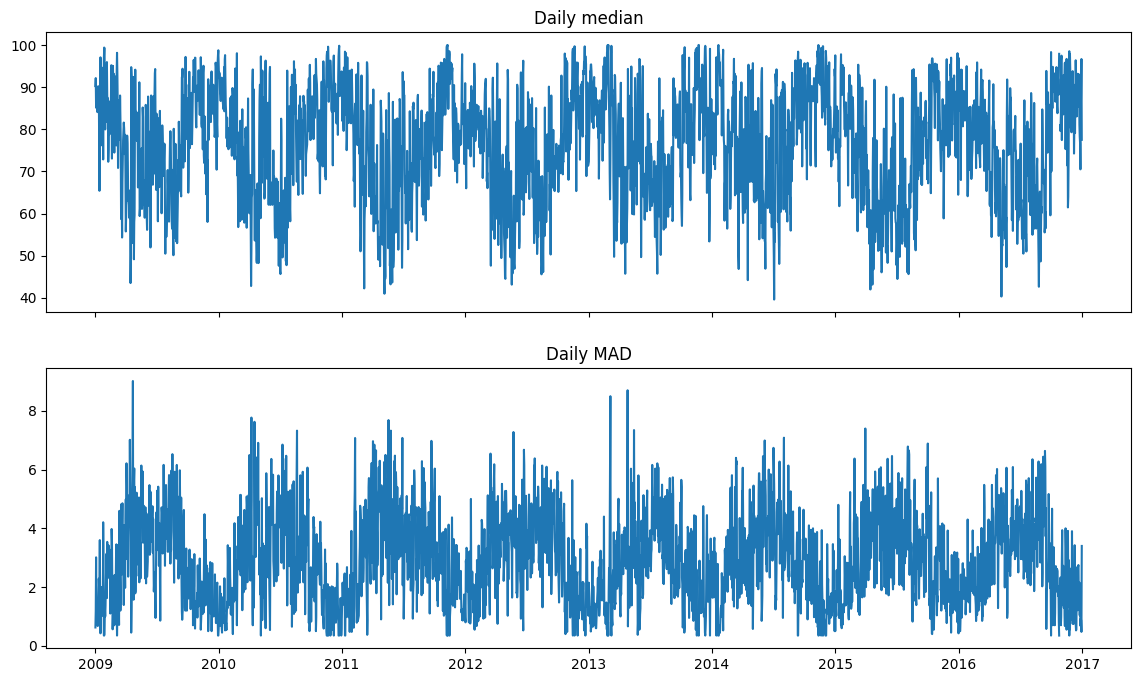

In [92]:
var = "rh (%)"
w_name = "3h"

median_t = df[f"{var}_median_{w_name}"]
mad_t = df[f"{var}_mad_{w_name}"]

daily = median_t.resample("D").median()
mad_daily = mad_t.resample("D").median()

fig, ax = plt.subplots(2,1,figsize=(14,8), sharex=True)
ax[0].plot(daily); ax[0].set_title("Daily median")
ax[1].plot(mad_daily); ax[1].set_title("Daily MAD")
plt.show()

## agreement analysis

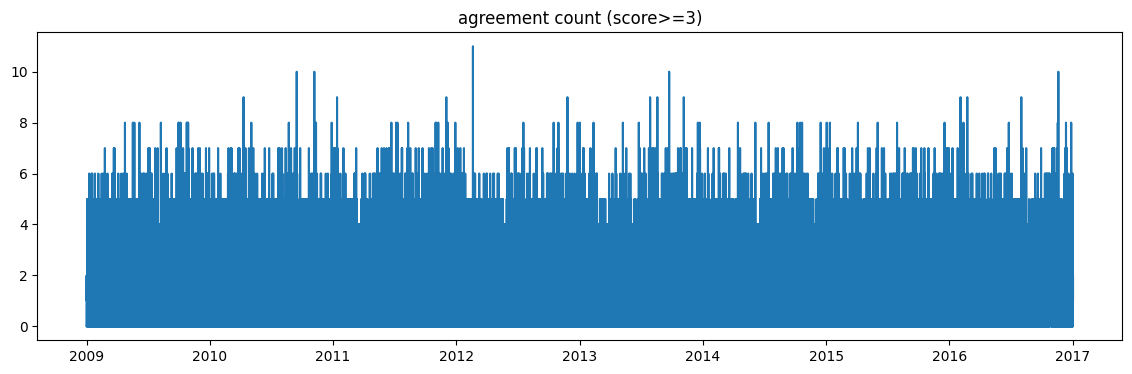

In [78]:
threshold = 3

score_cols = [c for c in df.columns if c.endswith(f"_score_1h")]
score_cols += [c for c in df.columns if c.endswith(f"_score_3h")]
score_cols += [c for c in df.columns if c.endswith(f"_score_12h")]

agreement = (df[score_cols] >= threshold).sum(axis=1)

plt.figure(figsize=(14,4))
plt.plot(agreement)
plt.title("agreement count (score>=3)")
plt.show()

## synthetic test

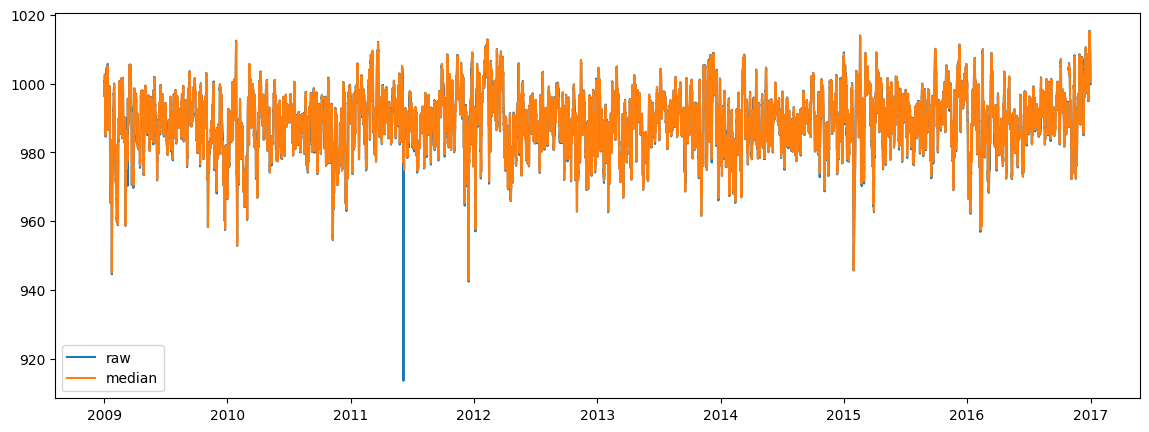

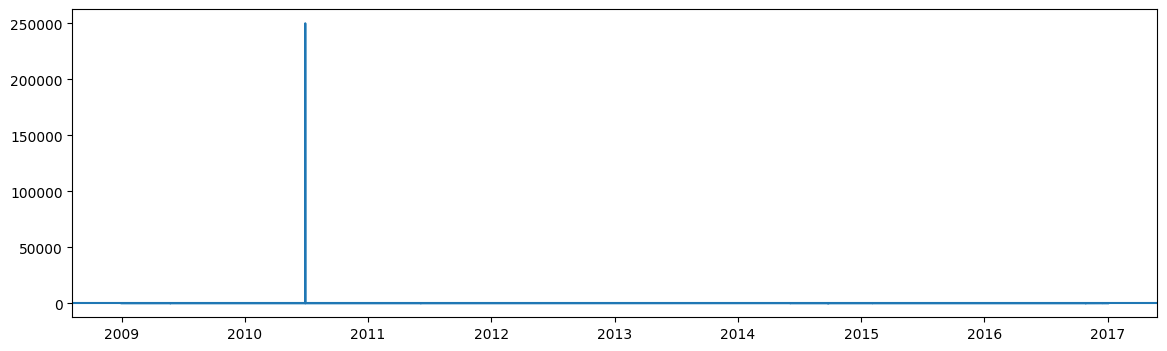

In [95]:
test = raw_df.copy()

# Inject a pressure drop
t0 = test.index[10000]
test.loc[t0:t0+pd.Timedelta("40min"), "p (mbar)"] -= 20

raw = test["p (mbar)"]

median_t = raw.rolling(window=18, min_periods=18).median()
mad_t = (raw - median_t).abs().rolling(window=18, min_periods=18).median()
mad_t = mad_t.clip(lower=1e-6)

score = (raw - median_t).abs() / mad_t

plt.figure(figsize=(14,5))
plt.plot(raw, label="raw")
plt.plot(median_t, label="median")
plt.legend()
plt.show()

plt.figure(figsize=(14,4))
plt.plot(score, label="score")
plt.axhline(5)
plt.show()


In [81]:
stats = {}

for col in cols:
    for w_name in windows:
        s = df[f"{col}_score_{w_name}"]
        stats[f"{col}_{w_name}"] = {
            "p3": float((s>=3).mean()*100),
            "p5": float((s>=5).mean()*100),
            "p8": float((s>=8).mean()*100),
            "median": float(np.nanmedian(s)),
            "p95": float(np.nanpercentile(s,95)),
        }

stats


{'p (mbar)_1h': {'p3': 5.636135913700457,
  'p5': 1.611580756095416,
  'p8': 0.30349338232323353,
  'median': 0.9945945924442473,
  'p95': 3.2222221864200415},
 'p (mbar)_3h': {'p3': 6.045863862897994,
  'p5': 1.4485451568207584,
  'p8': 0.24883130093377095,
  'median': 0.9868421026663683,
  'p95': 3.2592592109745615},
 'p (mbar)_12h': {'p3': 8.65823603086744,
  'p5': 2.744749469421319,
  'p8': 0.6854149683791743,
  'median': 0.9870129857311635,
  'p95': 3.9036729445348173},
 'T (degC)_1h': {'p3': 6.459869714117314,
  'p5': 2.0182191093883315,
  'p8': 0.5599298424068427,
  'median': 0.9801980178609945,
  'p95': 3.386363620971072},
 'T (degC)_3h': {'p3': 8.140847547455005,
  'p5': 2.643268127015664,
  'p8': 0.7291446334907443,
  'median': 0.9590973196281549,
  'p95': 3.818750667401911},
 'T (degC)_12h': {'p3': 5.783723533452005,
  'p5': 1.6479429232805807,
  'p8': 0.4254135899440783,
  'median': 0.9800796807542734,
  'p95': 3.2075279119361344},
 'rh (%)_1h': {'p3': 7.602544876380514,
  

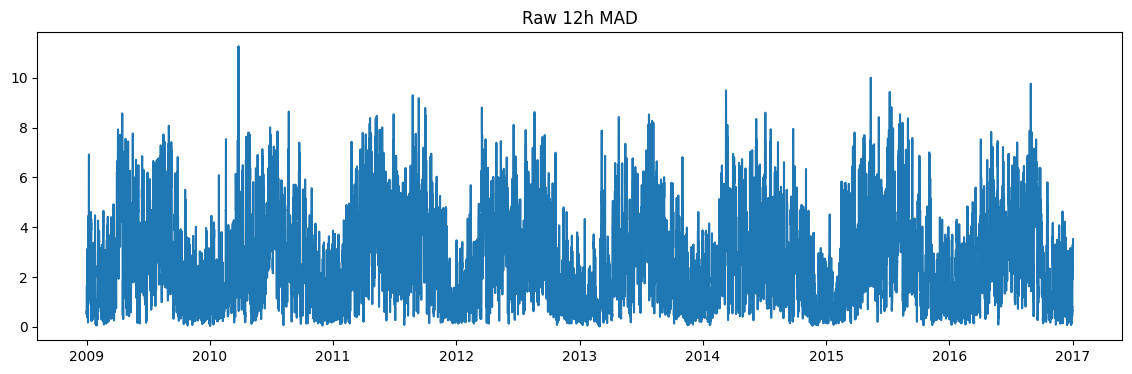

Exact zeros: 0
Very small (<1e-3): 0


In [100]:
raw = raw_df["T (degC)"]

mad_raw = (raw - raw.rolling("12h", min_periods=18).median()).abs() \
            .rolling("12h", min_periods=18).median()

plt.figure(figsize=(14,4))
plt.plot(mad_raw)
plt.title("Raw 12h MAD")
plt.show()

print("Exact zeros:", (mad_raw == 0).sum())
print("Very small (<1e-3):", (mad_raw < 1e-3).sum())
